# Capability 04 — Behaviour intelligence

Executed evidence over in-memory seed facts. Rule traits are assigned in `src/`. Clustering is a notebook experiment only and does not become a served model.

In [1]:
from pathlib import Path
import json
from datetime import datetime, timedelta
from decimal import Decimal
import matplotlib.pyplot as plt
import pandas as pd
from telco_digital.application.clock import FixedClock
from telco_digital.application.seed import seed_demo_customers
from telco_digital.infrastructure.memory import InMemoryUnitOfWork
from telco_digital.intelligence.behaviour import assign_traits, build_behaviour
from telco_digital.intelligence.event_memory import EventMemoryService
from telco_digital.intelligence.event_memory.uow import UnitOfWorkEventMemoryQueries
from telco_digital.intelligence.features import CustomerFeatures, GraphFeatures
from telco_digital.intelligence.features.service import FeatureGroup

ROOT = Path("outputs")
for folder in ("tables", "plots", "artifacts"):
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
AS_OF = datetime.fromisoformat("2026-08-21T00:00:00+00:00")

async def features_from_uow(uow, customer_ref):
    customer = await uow.customers.get_by_ref(customer_ref)
    window = AS_OF - timedelta(days=30)
    recharges = [row for row in await uow.recharges.list_as_of(customer.id, AS_OF) if row.occurred_at >= window]
    small = sum(row.amount <= Decimal("500") for row in recharges)
    amount = float(sum((row.amount for row in recharges), Decimal("0")))
    usage = [row for row in await uow.usage_events.list_as_of(customer.id, AS_OF) if row.occurred_at >= window]
    mb = float(sum((row.data_mb for row in usage), Decimal("0")))
    travels = list(await uow.travels.list_as_of(customer.id, AS_OF))
    roam = sum(max(0, ((row.ended_at if row.ended_at and row.ended_at <= AS_OF else AS_OF) - row.started_at).days) for row in travels)
    service = list(await uow.service_interactions.list_by_customer(customer.id))
    complaints = sum(row.interaction_type == "COMPLAINT" and row.occurred_at <= AS_OF for row in service)
    open_count = sum(row.status == "OPEN" and row.occurred_at <= AS_OF for row in service)
    return CustomerFeatures(
        customer_id=customer.id, customer_ref=customer_ref, as_of=AS_OF, computed_at=AS_OF,
        temporal={
            "recharge": FeatureGroup(window_days=30, values={"small_recharge_count_30d": small, "frequent_small_recharge_evidence": small >= 3, "amount_30d": amount}),
            "usage": FeatureGroup(window_days=30, values={"data_mb_30d": mb, "data_mb_90d": mb, "data_mb_change_ratio": None}),
            "travel": FeatureGroup(window_days=365, values={"trip_count_365d": len(travels), "roaming_days_365d": roam}),
            "service": FeatureGroup(window_days=90, values={"complaint_count_90d": complaints, "open_count": open_count}),
            "campaign": FeatureGroup(window_days=90, values={"conversion_count_90d": 0, "conversion_rate_90d": None}),
        },
        graph=GraphFeatures(available=False, values={}), provenance=("in-memory seed",),
    )

uow = InMemoryUnitOfWork()
await seed_demo_customers(uow, clock=FixedClock(datetime.fromisoformat("2026-08-27T00:00:00+00:00")))
memory = EventMemoryService(UnitOfWorkEventMemoryQueries(uow))
refs = ["U001", "U002", "U003", "U004", "U005"]
rows = []
for ref in refs:
    features = await features_from_uow(uow, ref)
    recalled = await memory.recall(ref, AS_OF)
    document = build_behaviour(features, recalled.historical_episodes)
    rows.append({"customer_ref": ref, "traits": [item.trait for item in document.traits], "document": document, "features": features})
len(rows)

5

In [2]:
u002 = next(row for row in rows if row["customer_ref"] == "U002")
u001 = next(row for row in rows if row["customer_ref"] == "U001")
assert "PRICE_SENSITIVE" in u002["traits"]
assert "FREQUENT_TRAVELLER" in u001["traits"]
golden = [{"customer_ref": row["customer_ref"], "traits": row["traits"]} for row in rows]
u002_trait = next(item for item in u002["document"].traits if item.trait == "PRICE_SENSITIVE")
price = {"trait": u002_trait.trait, "confidence": u002_trait.confidence, "evidence": u002_trait.evidence}
(ROOT / "tables" / "u002_price_sensitive.json").write_text(json.dumps(price, indent=2) + "\n", encoding="utf-8")
(ROOT / "tables" / "golden_traits.json").write_text(json.dumps(golden, indent=2) + "\n", encoding="utf-8")
pd.DataFrame(golden)

,customer_ref,traits
0,U001,"[HEAVY_DATA_USER, FREQUENT_TRAVELLER, STREAMIN..."
1,U002,[PRICE_SENSITIVE]
2,U003,[HIGH_VALUE]
3,U004,[DECLINING_ENGAGEMENT]
4,U005,[]


In [3]:
from telco_digital.application.demo_dataset import SEED_PERSONAS
vectors = []
for row in rows:
    values = {}
    for group in row["features"].temporal.values():
        values.update({key: (0 if value is None or isinstance(value, bool) else float(value) if isinstance(value, (int, float)) else 0) for key, value in group.values.items() if not isinstance(value, str)})
        values.update({key: int(value) for key, value in group.values.items() if isinstance(value, bool)})
    vectors.append(values)
frame = pd.DataFrame(vectors).fillna(0)
labels = [SEED_PERSONAS[row["customer_ref"]] for row in rows]
try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    clustered = KMeans(n_clusters=min(4, len(frame)), n_init=10, random_state=20260831).fit_predict(StandardScaler().fit_transform(frame))
except Exception:
    clustered = list(range(len(frame)))
comparison = pd.DataFrame({"customer_ref": refs, "persona": labels, "cluster": clustered})
(ROOT / "tables" / "cluster_vs_persona.json").write_text(comparison.to_json(orient="records", indent=2) + "\n", encoding="utf-8")
comparison

,customer_ref,persona,cluster
0,U001,FREQUENT_TRAVELLER,3
1,U002,PRICE_SENSITIVE,0
2,U003,STABLE_HIGH_VALUE,2
3,U004,DECLINING_ENGAGEMENT,1
4,U005,WALLET_FRAUD_CLUSTER,2


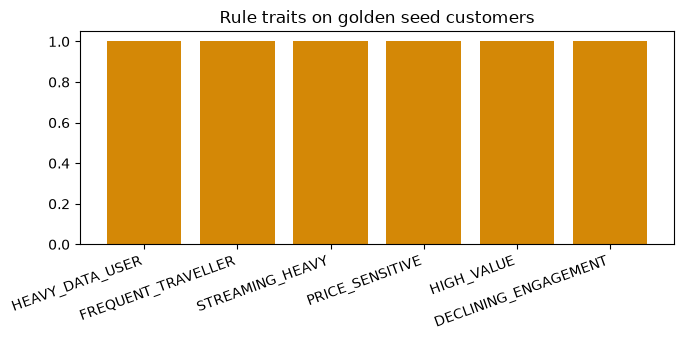

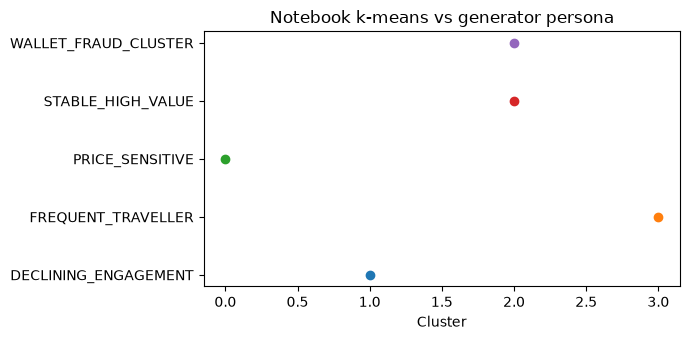

{'behaviour_set_version': 'customer-behaviour-v1',
 'synthetic_poc': True,
 'golden_customers': 5,
 'u002_price_sensitive': True,
 'u001_frequent_traveller': True,
 'trait_count': 6,
 'cluster_count': 4,
 'online_clustering': False}

In [4]:
trait_counts = pd.Series([trait for row in rows for trait in row["traits"]]).value_counts()
metrics = {
    "behaviour_set_version": "customer-behaviour-v1",
    "synthetic_poc": True,
    "golden_customers": len(rows),
    "u002_price_sensitive": "PRICE_SENSITIVE" in u002["traits"],
    "u001_frequent_traveller": "FREQUENT_TRAVELLER" in u001["traits"],
    "trait_count": int(trait_counts.sum()) if len(trait_counts) else 0,
    "cluster_count": int(comparison["cluster"].nunique()),
    "online_clustering": False,
}
(ROOT / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n", encoding="utf-8")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(trait_counts.index, trait_counts.values, color="#d48806")
ax.set_title("Rule traits on golden seed customers")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(ROOT / "plots" / "trait_counts.png", dpi=120)
plt.show()
fig, ax = plt.subplots(figsize=(7, 3.5))
for persona, group in comparison.groupby("persona"):
    ax.scatter(group["cluster"], [persona] * len(group), label=persona)
ax.set_xlabel("Cluster")
ax.set_title("Notebook k-means vs generator persona")
fig.tight_layout()
fig.savefig(ROOT / "plots" / "cluster_vs_persona.png", dpi=120)
plt.show()
metrics